<a href="https://colab.research.google.com/github/pang-lang/404Found/blob/main/Market%20Volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
!pip install pandas numpy matplotlib scikit-learn xgboost
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Load the dataset
file_path = 'UM_datathon_2024.csv'
data = pd.read_csv(file_path)

# Ensure time column is properly parsed as datetime
data['time'] = pd.to_datetime(data['time'])

# Sort by time in case the data is not ordered
data.sort_values(by='time', inplace=True)

# Step 1: Calculate Price-Based Volatility
data['price_volatility'] = (data['high_price'] - data['low_price']) / data['close_price']
data['price_volatility_rolling'] = data['price_volatility'].rolling(window=30).mean()

# Step 2: Thresholds for Volatility Classification
high_threshold = data['price_volatility_rolling'].quantile(0.70)
low_threshold = data['price_volatility_rolling'].quantile(0.30)

# Function to classify price volatility
def classify_price_volatility(volatility, high, low):
    if volatility > high:
        return 'High Volatility'
    elif volatility < low:
        return 'Low Volatility'
    else:
        return 'Medium Volatility'

data['volatility_class'] = data['price_volatility_rolling'].apply(
    lambda x: classify_price_volatility(x, high=high_threshold, low=low_threshold)
)


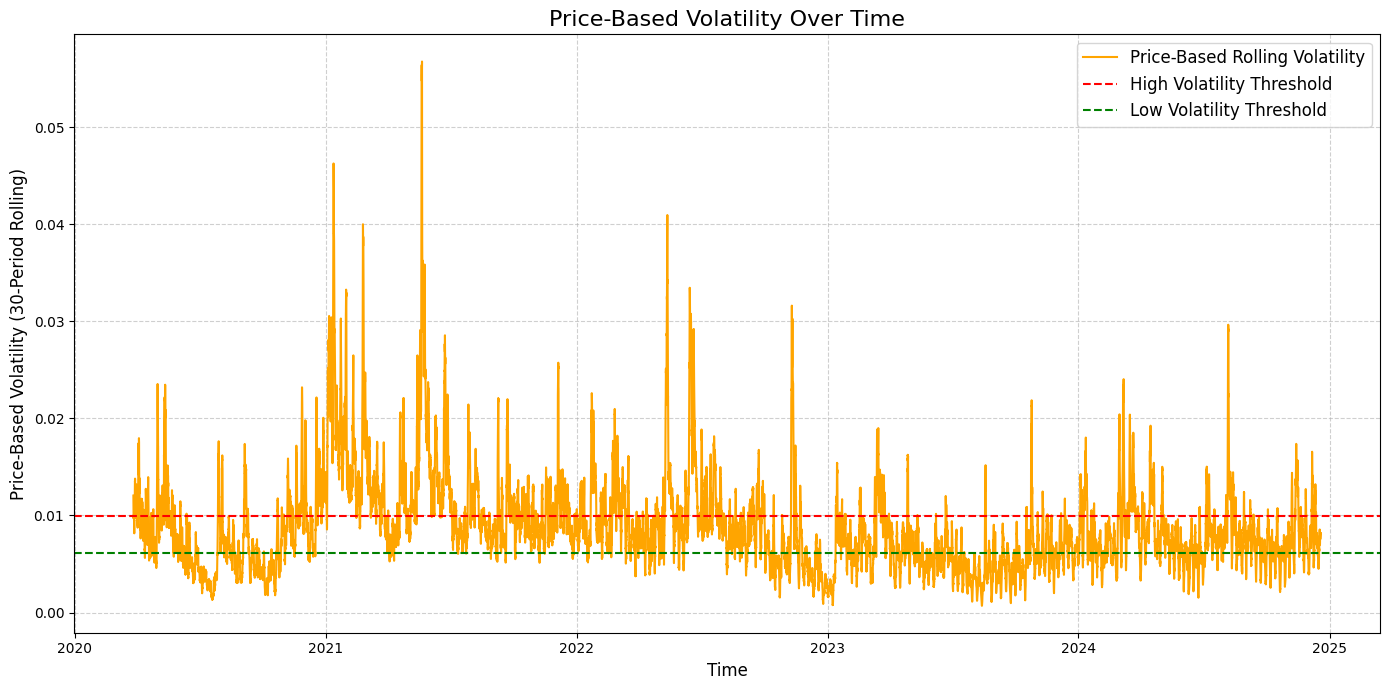

High Volatility Threshold: 0.009912592109670222
Low Volatility Threshold: 0.0061714496943869315
                  time  price_volatility  price_volatility_rolling  \
29 2020-03-26 15:00:00          0.008017                  0.012052   
30 2020-03-26 16:00:00          0.009571                  0.011909   
31 2020-03-26 17:00:00          0.010105                  0.011370   
32 2020-03-26 18:00:00          0.003846                  0.011060   
33 2020-03-26 19:00:00          0.005634                  0.010319   

   volatility_class  
29  High Volatility  
30  High Volatility  
31  High Volatility  
32  High Volatility  
33  High Volatility  


In [47]:
# Step 3: Plotting Price-Based Rolling Volatility
plt.figure(figsize=(14, 7))
plt.plot(data['time'], data['price_volatility_rolling'], label='Price-Based Rolling Volatility', color='orange')
plt.title('Price-Based Volatility Over Time', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Price-Based Volatility (30-Period Rolling)', fontsize=12)
plt.axhline(y=high_threshold, color='red', linestyle='--', label='High Volatility Threshold')
plt.axhline(y=low_threshold, color='green', linestyle='--', label='Low Volatility Threshold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display a sample of the classified data
print(f"High Volatility Threshold: {high_threshold}")
print(f"Low Volatility Threshold: {low_threshold}")
print(data[['time', 'price_volatility', 'price_volatility_rolling', 'volatility_class']].dropna().head())


In [48]:
# Step 4: Regression Analysis (Behavioral Study)
# Prepare independent variables and dependent variable
independent_vars = [
    'coinbase_premium_gap',
    'exchange_whale_ratio',
    'coinbase_premium_index',
    'taker_sell_ratio',
    'long_liquidations',
    'short_liquidations',
    'volume',
    'addresses_count_active',
    'exchange_supply_ratio',
    'tokens_transferred_total',
    'transactions_count_inflow'
]

# Drop rows with missing values
data_clean = data.dropna(subset=['price_volatility'] + independent_vars)

# Dependent variable: price volatility
y = data_clean['price_volatility']

# Add constant term for the regression
X = data_clean[independent_vars]


In [49]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (important for XGBoost)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and fit Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)


In [50]:
# Initialize and fit XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
xgb_predictions = xgb_model.predict(X_test_scaled)

# Evaluate the model
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)


In [51]:
# Compare model metrics
metrics = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MSE': [rf_mse, xgb_mse],
    'R2 Score': [rf_r2, xgb_r2]
})
print(metrics)

           Model       MSE  R2 Score
0  Random Forest  0.000016  0.777727
1        XGBoost  0.000014  0.808944


XGBoost outperformed Random Forest, achieving a slightly better mean squared error (MSE) and a higher R² score. The higher R² score of XGBoost indicates it explains about 80.89% of the variance in the data, compared to 77.77% for Random Forest.

In [58]:
feature_importance_rf = rf_model.feature_importances_
feature_importance_xgb = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': independent_vars,
    'Random Forest Importance': feature_importance_rf,
    'XGBoost Importance': feature_importance_xgb
}).sort_values('XGBoost Importance', ascending=False)

print(importance_df)


                      Feature  Random Forest Importance  XGBoost Importance
4           long_liquidations                  0.315861            0.322232
5          short_liquidations                  0.228555            0.277645
6                      volume                  0.231176            0.151118
0        coinbase_premium_gap                  0.048070            0.054083
8       exchange_supply_ratio                  0.060073            0.047988
10  transactions_count_inflow                  0.020075            0.047939
3            taker_sell_ratio                  0.033223            0.032268
9    tokens_transferred_total                  0.016119            0.021316
2      coinbase_premium_index                  0.019801            0.020067
7      addresses_count_active                  0.012400            0.013172
1        exchange_whale_ratio                  0.014646            0.012172


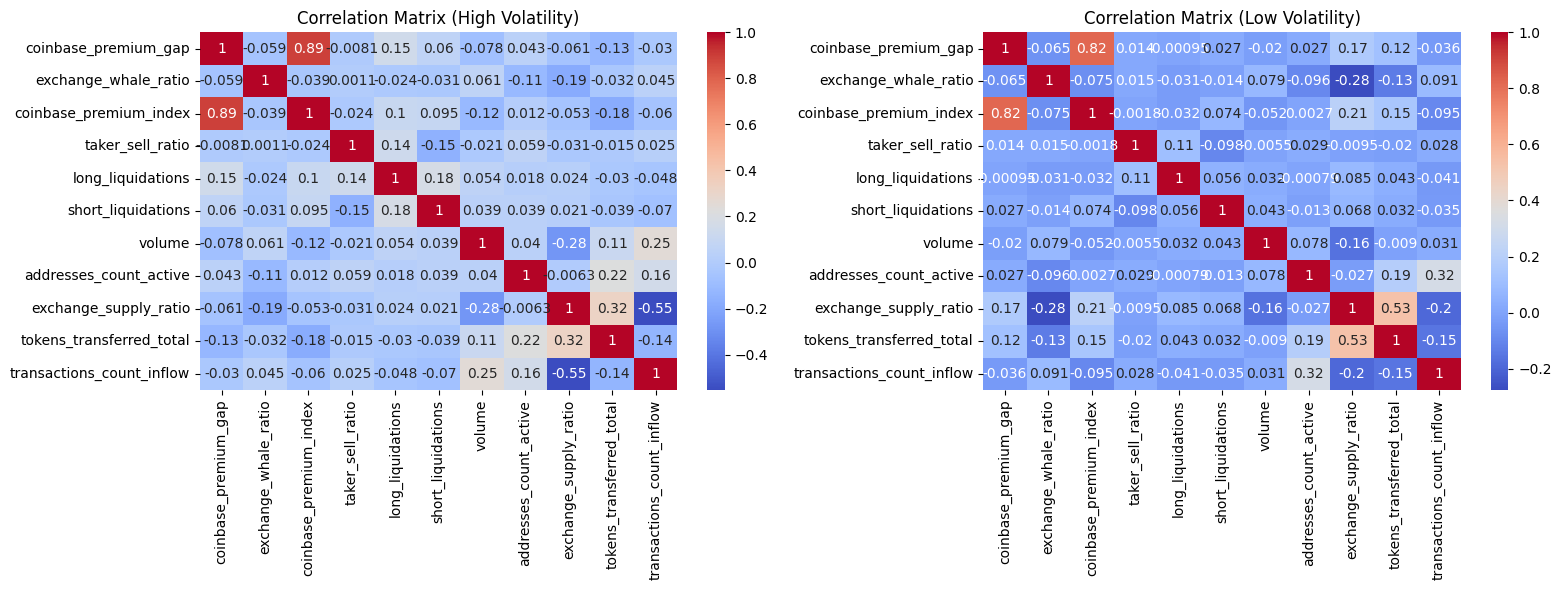

In [56]:
# Filter data by volatility class
high_vol_data = data[data['volatility_class'] == 'High Volatility']
low_vol_data = data[data['volatility_class'] == 'Low Volatility']

# Calculate correlation matrices for all factors
high_corr = high_vol_data[independent_vars].corr()
low_corr = low_vol_data[independent_vars].corr()

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(high_corr, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Matrix (High Volatility)')
sns.heatmap(low_corr, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Matrix (Low Volatility)')
plt.tight_layout()
plt.show()
